In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("retail_sales.csv")

In [3]:
print(df.head())

   Order_ID     Product     Category Region  Quantity  Sales  Discount
0      1001      Laptop  Electronics  North         2  80000        10
1      1002      Mobile  Electronics  South         3  45000         5
2      1003  Headphones  Electronics   East         5  10000        15
3      1004       Chair    Furniture   West         4  12000        10
4      1005       Table    Furniture  North         2  15000         5


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Order_ID  20 non-null     int64
 1   Product   20 non-null     str  
 2   Category  20 non-null     str  
 3   Region    20 non-null     str  
 4   Quantity  20 non-null     int64
 5   Sales     20 non-null     int64
 6   Discount  20 non-null     int64
dtypes: int64(4), str(3)
memory usage: 1.2 KB
None


In [5]:
print(df.describe())

         Order_ID   Quantity         Sales   Discount
count    20.00000  20.000000      20.00000  20.000000
mean   1010.50000   2.900000   33800.00000  10.250000
std       5.91608   1.410487   27538.68093   4.529145
min    1001.00000   1.000000    9000.00000   5.000000
25%    1005.75000   2.000000   15000.00000   7.250000
50%    1010.50000   3.000000   23500.00000  10.000000
75%    1015.25000   4.000000   42750.00000  12.000000
max    1020.00000   6.000000  120000.00000  20.000000


In [6]:
print(df.isnull().sum())

Order_ID    0
Product     0
Category    0
Region      0
Quantity    0
Sales       0
Discount    0
dtype: int64


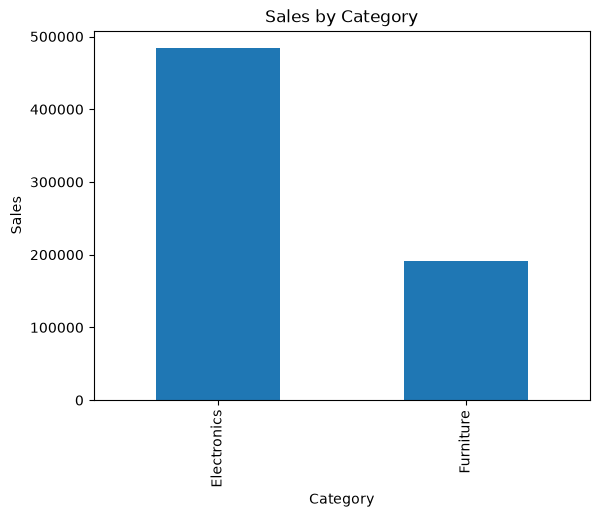

In [7]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

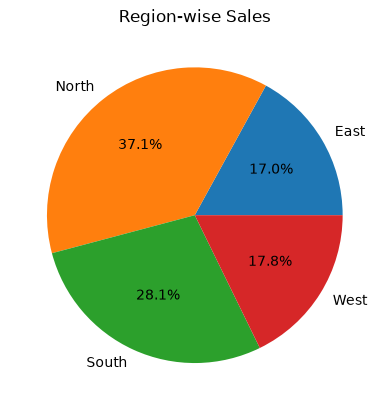

In [8]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Region-wise Sales")
plt.ylabel("")
plt.show()

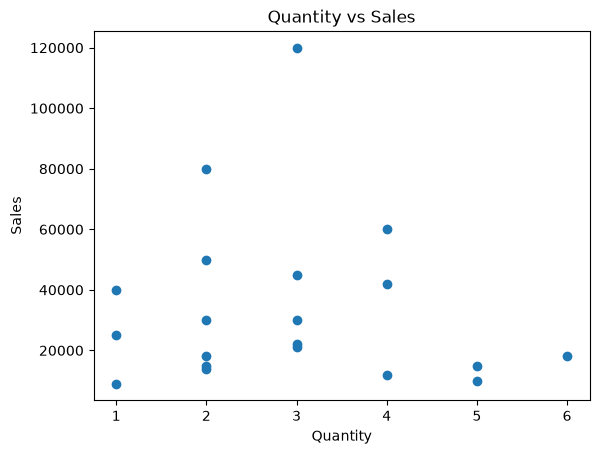

In [9]:
plt.scatter(df['Quantity'], df['Sales'])
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

In [10]:
le_product = LabelEncoder()
le_category = LabelEncoder()
le_region = LabelEncoder()

In [11]:
df['Product'] = le_product.fit_transform(df['Product'])
df['Category'] = le_category.fit_transform(df['Category'])
df['Region'] = le_region.fit_transform(df['Region'])

In [12]:
X = df[['Product','Category','Region','Quantity','Discount']]
y = df['Sales']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
model = RandomForestRegressor(n_estimators=100,random_state=42)

In [15]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [16]:
y_pred = model.predict(X_test)

In [17]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.016504136006089576
